# HRF Feature Analysis

### Imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / "benchmark"))
from maskel.config import ExtractionConfig, OutputConfig, PipelineConfig
from maskel.pipeline import analyze_segmentation_mask

from hrf import HRFDataset, preprocess_segmentation

### Load Data

In [2]:
# Init HRF dataset
dataset = HRFDataset("../data/HRF")

# Config with ALL features and cleanup enabled
config = PipelineConfig(
    extraction=ExtractionConfig(
        branches=True,
        nodes=True,
        summary=True,
        fractal_dimension=True,
        mask_radius=True,
        junction_cleanup=True,
        cleanup_threshold_factor=2.5,
        closing_iterations=0,
        fill_holes=True,
        max_hole_size=300,
    ),
    output=OutputConfig(),
)

# Process all 45 HRF samples through maskel with full feature extraction
results = []
all_branch_records = {}
all_node_records = {}
for i in range(len(dataset)):
    print(f"Processing sample {i + 1}/{len(dataset)}")
    _, seg, mask, info = dataset.load_sample(i)
    binary = preprocess_segmentation(seg, mask, min_size=50)
    result = analyze_segmentation_mask(binary, config)
    row = {"image": info["name"], **result.summary_features[0]}
    results.append(row)
    if result.branch_records:
        all_branch_records[info["name"]] = pd.DataFrame(result.branch_records)
    if result.node_records:
        all_node_records[info["name"]] = pd.DataFrame(result.node_records)

df = pd.DataFrame(results).set_index("image")

# Stack branch/node records across images for multi-image analysis
branch_df = pd.concat(
    [d.assign(image=name) for name, d in all_branch_records.items()],
    ignore_index=True,
)
node_df = pd.concat(
    [d.assign(image=name) for name, d in all_node_records.items()],
    ignore_index=True,
)

phenotype_map = {"h": "healthy", "dr": "diabetes", "g": "glaucoma"}
sample_meta = pd.DataFrame(index=df.index)
sample_meta["sample_suffix"] = (
    sample_meta.index.to_series().astype(str).str.split("_").str[-1]
)
sample_meta["phenotype"] = (
    sample_meta["sample_suffix"].map(phenotype_map).fillna("unknown")
)

# Map phenotype labels onto branch and node records
phenotype_by_image = sample_meta["phenotype"].to_dict()
branch_df["phenotype"] = branch_df["image"].map(phenotype_by_image)
node_df["phenotype"] = node_df["image"].map(phenotype_by_image)

print(f"\nSummary features: {df.shape[0]} samples x {df.shape[1]} features")
print(
    f"Branch records:   {len(branch_df)} rows across {branch_df['image'].nunique()} images"
)
print(
    f"Node records:     {len(node_df)} rows across {node_df['image'].nunique()} images"
)
print(sample_meta["phenotype"].value_counts().sort_index().to_string())

Processing sample 1/45
[2026-09-04 11:24:46,999] Processing image of shape (2336, 3504) with spacing None
[2026-09-04 11:24:47,029] Processing 1 object(s)
[2026-09-04 11:25:12,802] Finished image of shape (2336, 3504) in 25.80s
Processing sample 2/45
[2026-09-04 11:25:13,960] Processing image of shape (2336, 3504) with spacing None
[2026-09-04 11:25:13,994] Processing 1 object(s)
[2026-09-04 11:25:24,845] Finished image of shape (2336, 3504) in 10.88s
Processing sample 3/45
[2026-09-04 11:25:25,505] Processing image of shape (2336, 3504) with spacing None
[2026-09-04 11:25:25,546] Processing 1 object(s)
[2026-09-04 11:25:32,906] Finished image of shape (2336, 3504) in 7.40s
Processing sample 4/45
[2026-09-04 11:25:34,091] Processing image of shape (2336, 3504) with spacing None
[2026-09-04 11:25:34,122] Processing 1 object(s)
[2026-09-04 11:25:40,069] Finished image of shape (2336, 3504) in 5.98s
Processing sample 5/45
[2026-09-04 11:25:40,678] Processing image of shape (2336, 3504) wi

### Inspect it

In [3]:
df.head()

,num_nodes,num_edges,num_endpoints,num_bifurcations,total_length,mean_length,std_length,max_length,min_length,mean_tortuosity,...,std_radius,min_radius,max_radius,mean_diameter,std_diameter,min_diameter,max_diameter,mean_segment_volume,mean_surface_area,object_id
image,,,,,,,,,,,,,,,,,,,,,
01_dr,328.0,361.0,132.0,196.0,55548.502202,153.873967,152.950641,913.837662,1.0,1.081076,...,3.664855,1.0,44.384682,8.182415,7.329709,2.0,88.769364,14699.638913,3982.265924,1
01_g,606.0,677.0,232.0,374.0,77236.595985,114.086552,100.894803,576.132034,1.0,1.080851,...,2.862744,1.0,25.179357,7.737767,5.725488,2.0,50.358713,8365.250097,2788.412403,1
01_h,694.0,726.0,316.0,378.0,86925.369932,119.731915,93.955897,556.269119,1.0,1.085998,...,3.321156,1.0,23.086793,10.390180,6.642312,2.0,46.173586,14455.922231,3932.049218,1
02_dr,506.0,544.0,217.0,289.0,71594.998513,131.608453,122.309353,789.901587,1.0,1.088649,...,3.086397,1.0,31.780497,7.911356,6.172795,2.0,63.560994,10457.339676,3288.787836,1
02_g,746.0,814.0,305.0,441.0,84690.109689,104.041904,88.074025,569.274170,1.0,1.083294,...,2.877691,1.0,18.000000,7.830102,5.755383,2.0,36.000000,7779.326947,2573.592161,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 45 entries, 01_dr to 15_h
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_nodes             45 non-null     float64
 1   num_edges             45 non-null     float64
 2   num_endpoints         45 non-null     float64
 3   num_bifurcations      45 non-null     float64
 4   total_length          45 non-null     float64
 5   mean_length           45 non-null     float64
 6   std_length            45 non-null     float64
 7   max_length            45 non-null     float64
 8   min_length            45 non-null     float64
 9   mean_tortuosity       45 non-null     float64
 10  std_tortuosity        45 non-null     float64
 11  num_components        45 non-null     float64
 12  mean_degree           45 non-null     float64
 13  max_degree            45 non-null     float64
 14  fractal_dimension     45 non-null     float64
 15  fractal_dimension_r2  45 non-null  

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_nodes,45.0,621.377778,136.518112,328.000000,527.000000,606.000000,718.000000,985.000000
num_edges,45.0,671.933333,151.256164,361.000000,567.000000,637.000000,769.000000,1049.000000
num_endpoints,45.0,260.600000,57.052368,132.000000,217.000000,260.000000,305.000000,429.000000
num_bifurcations,45.0,360.777778,83.753939,196.000000,304.000000,339.000000,408.000000,574.000000
total_length,45.0,77701.079195,9203.864509,55548.502202,72635.092235,77931.867197,84188.276211,96594.185510
mean_length,45.0,118.589576,14.396397,92.082160,109.056328,119.731915,128.230402,153.873967
std_length,45.0,104.576252,16.486919,72.125017,92.322604,103.600926,116.829162,152.950641
max_length,45.0,709.770654,125.456970,529.462987,623.203102,707.357431,787.989899,1156.815367
min_length,45.0,1.009205,0.061747,1.000000,1.000000,1.000000,1.000000,1.414214
mean_tortuosity,45.0,1.088999,0.011119,1.076769,1.081076,1.085387,1.091449,1.125395


### Phenotype summary

In [6]:
summary = (
    df.join(sample_meta["phenotype"]).groupby("phenotype").agg(["mean", "std", "count"])
)
summary.columns = ["_".join(col) for col in summary.columns]
summary.reset_index(inplace=True)
summary

,phenotype,num_nodes_mean,num_nodes_std,num_nodes_count,num_edges_mean,num_edges_std,num_edges_count,num_endpoints_mean,num_endpoints_std,num_endpoints_count,...,max_diameter_count,mean_segment_volume_mean,mean_segment_volume_std,mean_segment_volume_count,mean_surface_area_mean,mean_surface_area_std,mean_surface_area_count,object_id_mean,object_id_std,object_id_count
0,diabetes,581.866667,166.291425,15,638.733333,194.568191,15,235.0,57.464275,15,...,15,10424.428512,2407.581115,15,3230.403252,579.840910,15,1.0,0.0,15
1,glaucoma,683.533333,138.230070,15,739.866667,143.619968,15,285.8,65.435028,15,...,15,7914.056996,1416.967551,15,2703.253324,385.153981,15,1.0,0.0,15
2,healthy,598.733333,73.840046,15,637.200000,77.472760,15,261.0,35.542731,15,...,15,15109.456543,2427.521129,15,4118.521351,452.413846,15,1.0,0.0,15


### Feature distributions

/tmp/ipykernel_3519182/1446931430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_3519182/1446931430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_3519182/1446931430.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
/tmp/ipykernel_3519182/1446931430.py:10: FutureWarning: 

Passing `palette` without a

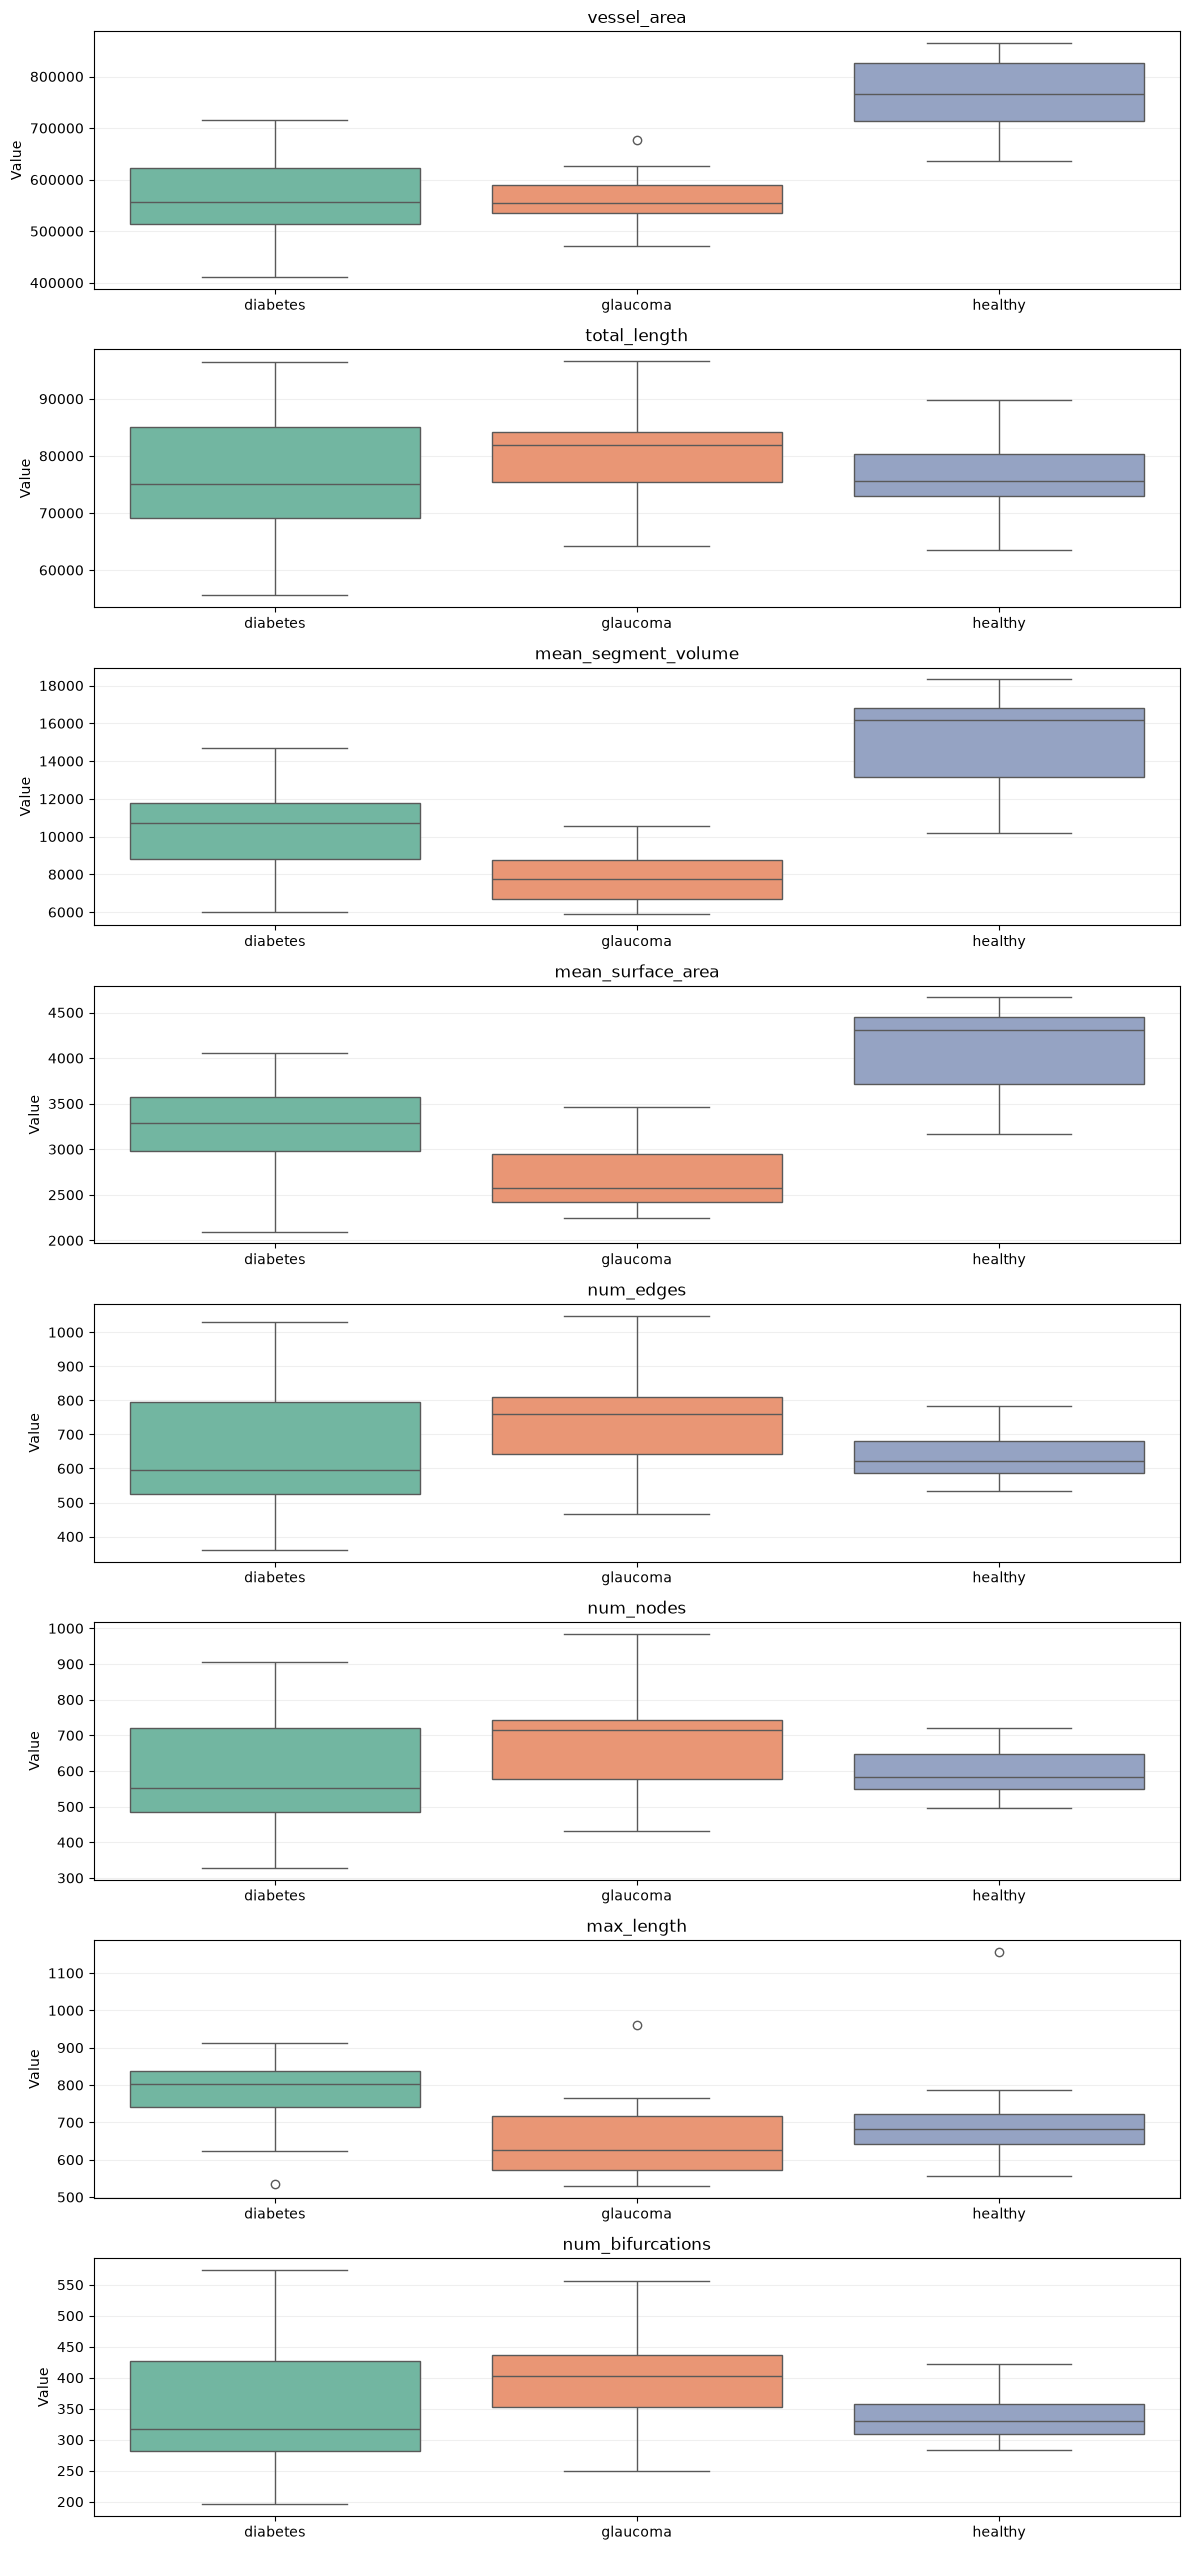

In [7]:
analysis_df = df.join(sample_meta["phenotype"])
variance_order = df.var().sort_values(ascending=False)
plot_features = variance_order.head(min(8, len(variance_order))).index.tolist()

fig, axes = plt.subplots(len(plot_features), 1, figsize=(12, 3.2 * len(plot_features)))
if len(plot_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, plot_features):
    sns.boxplot(data=analysis_df, x="phenotype", y=feature, ax=ax, palette="Set2")
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("./figures/feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Correlation

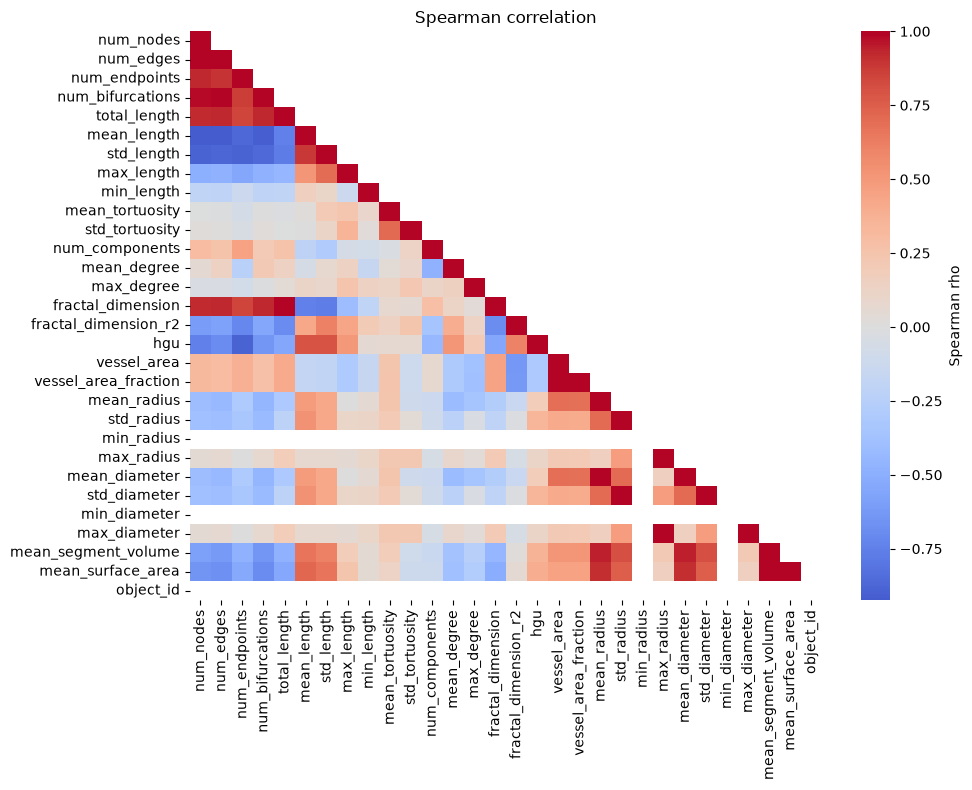

In [8]:
corr_spearman = df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool), k=1)
sns.heatmap(
    corr_spearman,
    annot=False,
    mask=mask,
    cmap="coolwarm",
    center=0,
    ax=ax,
    cbar_kws={"label": "Spearman rho"},
)
ax.set_title("Spearman correlation")

plt.tight_layout()
plt.savefig("./figures/correlation_heatmap.svg", bbox_inches="tight")
plt.show()

In [9]:
print("strongly correlated (abs(rho) > 0.8)")
upper = corr_spearman.where(np.triu(np.ones(corr_spearman.shape, dtype=bool), k=1))
upper.stack().rename("Spearman rho").rename_axis(["Feature 1", "Feature 2"]).loc[
    lambda s: s.abs() > 0.8
].sort_values(key=np.abs, ascending=False).reset_index()

strongly correlated (abs(rho) > 0.8)


,Feature 1,Feature 2,Spearman rho
0,max_radius,max_diameter,1.000000
1,std_radius,std_diameter,1.000000
2,mean_radius,mean_diameter,1.000000
3,vessel_area,vessel_area_fraction,0.999078
4,num_edges,num_bifurcations,0.994763
5,num_nodes,num_edges,0.993873
6,total_length,fractal_dimension,0.990250
7,mean_segment_volume,mean_surface_area,0.985112
8,num_nodes,num_bifurcations,0.981090
9,mean_diameter,mean_segment_volume,0.940580


### ANOVA Feature Difference

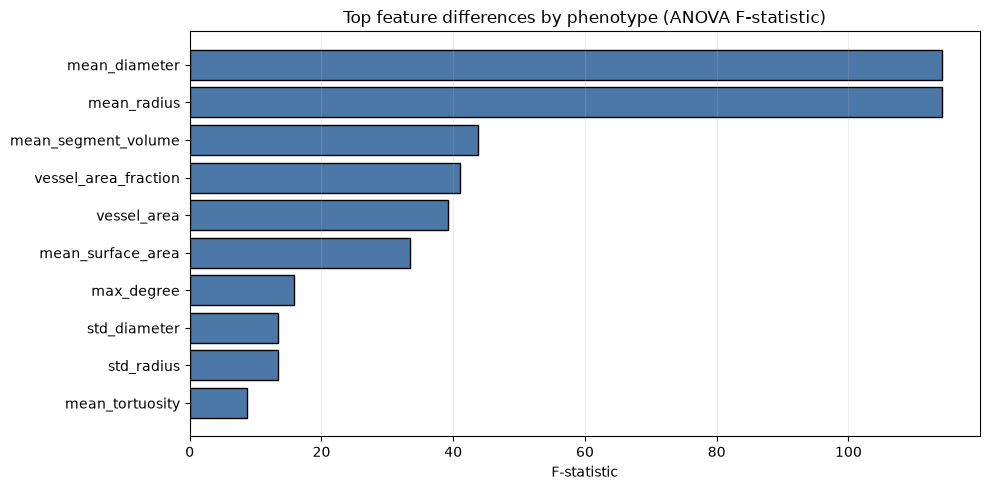

In [10]:
grouped = [group for _, group in analysis_df.groupby("phenotype")]

anova_rows = []
for feature in df.columns:
    feature_values = [group[feature].dropna() for group in grouped]
    f_stat, p_value = f_oneway(*feature_values)
    anova_rows.append({"Feature": feature, "F": f_stat, "p_value": p_value})

anova_df = pd.DataFrame(anova_rows).sort_values(
    ["p_value", "F"], ascending=[True, False]
)

top_anova = anova_df.head(10).sort_values("F")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_anova["Feature"], top_anova["F"], color="#4c78a8", edgecolor="black")
ax.set_title("Top feature differences by phenotype (ANOVA F-statistic)")
ax.set_xlabel("F-statistic")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("./figures/feature_difference_anova.svg", bbox_inches="tight")
plt.show()

In [11]:
anova_df.head(10)

,Feature,F,p_value
19,mean_radius,114.258271,1.028406e-17
23,mean_diameter,114.258271,1.028406e-17
27,mean_segment_volume,43.818698,5.258947e-11
18,vessel_area_fraction,41.077859,1.302968e-10
17,vessel_area,39.139680,2.536424e-10
28,mean_surface_area,33.402401,2.082695e-09
13,max_degree,15.895833,7.245717e-06
20,std_radius,13.350027,3.251894e-05
24,std_diameter,13.350027,3.251894e-05
9,mean_tortuosity,8.688907,6.952271e-04


In [12]:
from pathlib import Path

top_features = anova_df.head(10)["Feature"].tolist()
phenotype_order = ["healthy", "glaucoma", "diabetes"]
mean_by_phenotype = analysis_df.groupby("phenotype")[top_features].agg(["mean", "std"])
present_phenotypes = [
    phenotype for phenotype in phenotype_order if phenotype in mean_by_phenotype.index
]
formatted_mean_by_phenotype = pd.DataFrame(index=top_features)
for phenotype in present_phenotypes:
    formatted_mean_by_phenotype[phenotype] = [
        f"{mean_by_phenotype.loc[phenotype, (feature, 'mean')]:.3f} ± {mean_by_phenotype.loc[phenotype, (feature, 'std')]:.3f}"
        for feature in top_features
    ]
formatted_mean_by_phenotype.index.name = "feature"

repo_root = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
tex_path = repo_root / "tables" / "top_anova_feature_means.tex"
tex_path.parent.mkdir(parents=True, exist_ok=True)
latex_table = formatted_mean_by_phenotype.copy()
latex_table.index = latex_table.index.str.replace("_", r"\_", regex=False)
latex_table.to_latex(
    tex_path,
    escape=False,
    index=True,
    column_format="lccc",
    position="htb",
    caption=r"Mean $\pm$ standard deviation for the top 10 ANOVA features grouped by phenotype.",
    label="tab:top-anova-feature-means",
)
tex_path  # noqa: B018
formatted_mean_by_phenotype

,healthy,glaucoma,diabetes
feature,,,
mean_radius,5.387 ± 0.409,3.862 ± 0.189,4.095 ± 0.250
mean_diameter,10.774 ± 0.818,7.725 ± 0.379,8.189 ± 0.500
mean_segment_volume,15109.457 ± 2427.521,7914.057 ± 1416.968,10424.429 ± 2407.581
vessel_area_fraction,0.101 ± 0.010,0.074 ± 0.006,0.075 ± 0.011
vessel_area,762400.333 ± 73496.790,563082.333 ± 48977.013,566733.000 ± 84563.932
mean_surface_area,4118.521 ± 452.414,2703.253 ± 385.154,3230.403 ± 579.841
max_degree,3.133 ± 0.352,3.467 ± 0.516,3.933 ± 0.258
std_radius,3.180 ± 0.243,2.743 ± 0.233,3.054 ± 0.238
std_diameter,6.360 ± 0.486,5.487 ± 0.466,6.107 ± 0.476
